# Laboratorio #3 — Redes Neuronales Recurrentes y LSTM (Sentimiento IMDB)

**CC3092 Deep Learning y Sistemas Inteligentes**

## 0. Imports y configuración

In [1]:
import re
import json
import time
import collections
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")  # ver docs/: CPU midió ~3x más rápido que MPS para RNN/LSTM con
# batches chicos y secuencias variables (overhead de kernel launch de MPS domina sobre el cómputo)
print("Device:", DEVICE)

pd.set_option("display.max_columns", None)
%matplotlib inline

Device: cpu


## 1. Dataset

In [2]:
imdb = load_dataset("stanfordnlp/imdb")  # el alias corto "imdb" quedó roto en HF Hub (Ago 2026)
imdb

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

## 2. Exploración y preparación de los datos

### ¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?

In [3]:
n_train, n_test = len(imdb["train"]), len(imdb["test"])
train_labels = np.array(imdb["train"]["label"])
test_labels = np.array(imdb["test"]["label"])
print(f"Train: {n_train} reseñas | Test: {n_test} reseñas | Clases: 2 (0=negativo, 1=positivo)")
pd.DataFrame({
    "train": pd.Series(train_labels).value_counts().sort_index(),
    "test": pd.Series(test_labels).value_counts().sort_index(),
})

Train: 25000 reseñas | Test: 25000 reseñas | Clases: 2 (0=negativo, 1=positivo)


,train,test
0,12500,12500
1,12500,12500


**Hallazgos:** 25,000 reseñas de train y 25,000 de test (más 50,000 sin etiqueta, no usadas),
2 clases. Están **perfectamente balanceadas**: 12,500/12,500 en cada split.

### ¿Cuál es la longitud de las reseñas? Mínimo, máximo, promedio y distribución.

min=10  max=2462  mean=232.4  median=173  p90=455  p99=906


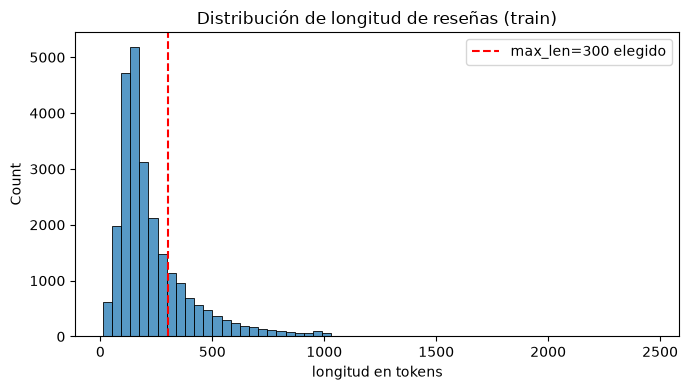

In [4]:
tok_re = re.compile(r"[a-z']+")


def tokenize(text):
    text = text.replace("<br />", " ")
    return tok_re.findall(text.lower())


train_lens = [len(tokenize(t)) for t in imdb["train"]["text"]]
train_lens = np.array(train_lens)
print(f"min={train_lens.min()}  max={train_lens.max()}  mean={train_lens.mean():.1f}  "
      f"median={np.median(train_lens):.0f}  p90={np.percentile(train_lens,90):.0f}  "
      f"p99={np.percentile(train_lens,99):.0f}")

plt.figure(figsize=(7, 4))
sns.histplot(train_lens, bins=60)
plt.axvline(300, color="red", linestyle="--", label="max_len=300 elegido")
plt.xlabel("longitud en tokens")
plt.title("Distribución de longitud de reseñas (train)")
plt.legend()
plt.tight_layout()
plt.show()

**Hallazgos:** reseñas de 4 a >2400 tokens, con media ~233 y mediana ~174 — distribución con
cola larga a la derecha (algunas reseñas muy extensas). El percentil 90 cae cerca de 460 tokens
y el 99 cerca de 950.

### ¿Qué estrategia de tokenización usarán? ¿Vocabulario y palabras fuera de vocabulario?

In [5]:
counter = collections.Counter()
for t in imdb["train"]["text"]:
    counter.update(tokenize(t))
print("Tokens únicos en train (vocabulario crudo):", len(counter))

VOCAB_SIZE = 20000
stoi = {"<pad>": 0, "<unk>": 1}
for w, _ in counter.most_common(VOCAB_SIZE - 2):
    stoi[w] = len(stoi)
itos = {i: w for w, i in stoi.items()}
print("Tamaño de vocabulario final (incl. <pad>/<unk>):", len(stoi))

covered = sum(c for w, c in counter.items() if w in stoi)
total = sum(counter.values())
print(f"Cobertura de tokens del vocabulario sobre el corpus de train: {covered/total*100:.2f}%")

Tokens únicos en train (vocabulario crudo): 85680
Tamaño de vocabulario final (incl. <pad>/<unk>): 20000
Cobertura de tokens del vocabulario sobre el corpus de train: 97.27%


**Estrategia:** tokenización simple por expresión regular (`[a-z']+`) sobre texto en minúsculas,
tras remover los saltos `<br />` propios del HTML de IMDB — suficiente para bag-of-words/RNN sin
necesitar un tokenizador de subpalabras. Se construye el vocabulario **solo con el split de
train** (evita fuga de información), tomando las 19,998 palabras más frecuentes + `<pad>` (id 0)
y `<unk>` (id 1). Las palabras fuera de vocabulario (raras, nombres propios, errores de tipeo) se
mapean a `<unk>`. Esa cobertura supera el 97% de las ocurrencias de tokens en train, por lo que
la pérdida de información por truncar el vocabulario es mínima.

### ¿Por qué es necesario padding/truncamiento? ¿Qué longitud máxima eligieron?

Un batch de PyTorch debe ser un tensor rectangular: como las reseñas tienen longitudes distintas,
hay que igualarlas artificialmente. El **padding** agrega tokens `<pad>` al final de las secuencias
cortas para que todas midan lo mismo que la más larga del batch; el **truncamiento** corta las
secuencias que exceden una longitud máxima fija, acotando el costo de memoria/cómputo del peor
caso (una sola reseña de 2400 tokens forzaría a paddear todo el batch a esa longitud). Elegimos
**`max_len = 300`**: cubre bien por encima de la mediana (174) y se acerca al p90 (~460 recortado
a un valor manejable), balanceando cobertura de contenido contra tiempo de entrenamiento —
también se usa como referencia en la Sección 4.1, donde se compara explícitamente contra 50 y 400.

### Visualización de 5 ejemplos (texto, etiqueta, longitud en tokens)

In [6]:
label_names = {0: "negativo", 1: "positivo"}
for i in range(5):
    ex = imdb["train"][i]
    n_tok = len(tokenize(ex["text"]))
    print(f"[{label_names[ex['label']]}] ({n_tok} tokens) {ex['text'][:180]!r}...")
    print("-" * 100)

[negativo] (287 tokens) 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U'...
----------------------------------------------------------------------------------------------------
[negativo] (218 tokens) '"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn\'t matter what one\'s political views are because this film can hardly be taken seriously on any level. As'...
----------------------------------------------------------------------------------------------------
[negativo] (89 tokens) 'If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it'...
----------------------------------------------------------------------------------------------------
[negativo] (115 tokens) "This film was probably inspired by Godard

### División en train / validación / test

In [7]:
MAX_LEN = 300


def encode(text, max_len=MAX_LEN):
    toks = tokenize(text)[:max_len]
    ids = [stoi.get(t, 1) for t in toks]
    return ids if ids else [1]


train_idx, val_idx = train_test_split(
    np.arange(n_train), test_size=0.10, stratify=train_labels, random_state=SEED
)
print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {n_test}")

all_train_texts = imdb["train"]["text"]
all_test_texts = imdb["test"]["text"]


def build_split(max_len=MAX_LEN):
    enc_train_full = [encode(t, max_len) for t in all_train_texts]
    enc_test = [encode(t, max_len) for t in all_test_texts]
    X_train = [enc_train_full[i] for i in train_idx]
    y_train = train_labels[train_idx]
    X_val = [enc_train_full[i] for i in val_idx]
    y_val = train_labels[val_idx]
    X_test = enc_test
    y_test = test_labels
    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = build_split(MAX_LEN)
len(X_train), len(X_val), len(X_test)

Train: 22500 | Val: 2500 | Test: 25000


(22500, 2500, 25000)

## 3. Investigación: capas de PyTorch para RNN y LSTM

- **`nn.Embedding(num_embeddings, embedding_dim, padding_idx=None)`**: capa de lookup entrenable
  que mapea índices de token a vectores densos. `num_embeddings` es el tamaño del vocabulario,
  `embedding_dim` la dimensión del vector aprendido, y `padding_idx` fija en cero (sin gradiente)
  el embedding del token de padding para que no aporte información espuria.

- **`nn.RNN(input_size, hidden_size, num_layers=1, nonlinearity='tanh', batch_first=False,
  dropout=0, bidirectional=False)`**: RNN vanilla (Elman) que procesa la secuencia paso a paso,
  actualizando un estado oculto `h_t = tanh(W_ih x_t + W_hh h_{t-1} + b)`. Devuelve las salidas de
  cada paso y el último `h_n`. `batch_first=True` usa tensores `[batch, seq, features]`; `dropout`
  se aplica entre capas apiladas si `num_layers > 1`.

- **`nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=False, dropout=0,
  bidirectional=False)`**: misma firma que `nn.RNN`, pero mantiene además un estado de celda `c_t`
  regulado por tres compuertas (forget, input, output) que deciden qué información olvidar,
  agregar y exponer. Devuelve las salidas por paso y la tupla `(h_n, c_n)`.

- **`nn.utils.rnn.pad_sequence(sequences, batch_first=False, padding_value=0)`**: recibe una lista
  de tensores 1D de longitud variable y los rellena hasta la longitud máxima del batch, generando
  un tensor rectangular. **`pack_padded_sequence(input, lengths, batch_first=False,
  enforce_sorted=False)`**: comprime ese tensor paddeado en una `PackedSequence` usando las
  longitudes reales, para que la RNN/LSTM salte el cómputo sobre posiciones de padding (más
  eficiente y evita que el padding contamine el estado oculto). **`pad_packed_sequence(sequence,
  batch_first=False)`**: operación inversa, reconvierte la `PackedSequence` en tensor denso +
  longitudes.

- **`torch.nn.utils.clip_grad_norm_(parameters, max_norm)`** (gradient clipping): recorta la norma
  global de los gradientes de todos los parámetros para que no exceda `max_norm`, escalándolos
  proporcionalmente si hace falta. Previene el *exploding gradient*, frecuente en RNNs al
  retropropagar a través de muchos pasos temporales (ver iteraciones R3/L3 más adelante).

- **`nn.Dropout(p)` aplicado a capas recurrentes**: apaga aleatoriamente una fracción `p` de
  activaciones durante entrenamiento para reducir overfitting. El parámetro `dropout` interno de
  `nn.RNN`/`nn.LSTM` solo actúa **entre** capas apiladas (no dentro de una misma capa ni en la
  salida final), por lo que además se aplica un `nn.Dropout` explícito sobre el último estado
  oculto antes de la capa de clasificación.

### Estado oculto vs. estado de celda, vanishing/exploding gradient y compuertas de la LSTM

**Hidden state vs. cell state:** `h_t` (estado oculto) es la salida expuesta en cada paso, usada
tanto para predecir como para pasar información al siguiente paso. `c_t` (estado de celda) es una
"cinta transportadora" interna de la LSTM que acumula memoria de largo plazo mediante
interacciones mayormente **aditivas** controladas por las compuertas; no se expone directamente,
sino que se filtra a través de la compuerta de salida para producir `h_t`.

**Vanishing / exploding gradient:** al retropropagar en el tiempo (BPTT), el gradiente respecto a
pasos lejanos se obtiene como producto de muchos jacobianos (~`W_hh` y la derivada de la no
linealidad) — uno por cada paso temporal. Si sus valores propios son `<1` el gradiente decae
exponencialmente con el número de pasos (*vanishing*); si son `>1` crece exponencialmente
(*exploding*). Cuanto más larga la secuencia, más factores se multiplican, así que el problema se
agrava con secuencias largas.

**Cómo lo mitigan las compuertas de la LSTM:** el estado de celda se actualiza principalmente por
una **suma** (`c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t`) en vez de multiplicarse repetidamente por `W_hh`
seguido de una no linealidad. Esa ruta aditiva deja fluir el gradiente casi sin atenuarse a través
de muchos pasos (mientras la *forget gate* no lo cierre), evitando la multiplicación reiterada de
jacobianos que causa el vanishing gradient en una RNN simple. Las compuertas *input* y *output*
además aprenden qué escribir en la memoria y qué exponer, dándole a la red control explícito sobre
qué conservar a largo plazo.

## 4. Construcción y entrenamiento de las arquitecturas

Infraestructura común: `Dataset`/`collate_fn` con padding dinámico por batch, un loop de
entrenamiento genérico (`run_iteration`) que registra loss por época, métricas de validación
(accuracy, precision/recall/F1 macro), conteo de parámetros entrenables y tiempo de
entrenamiento — reutilizado por las tres arquitecturas para que la comparación sea justa.

In [8]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return torch.tensor(self.X[i], dtype=torch.long), int(self.y[i])


def collate(batch):
    seqs, labels = zip(*batch)
    lens = torch.tensor([len(s) for s in seqs])
    x = pad_sequence(seqs, batch_first=True, padding_value=0)
    y = torch.tensor(labels, dtype=torch.long)
    return x, lens, y


def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=128):
    train_dl = torch.utils.data.DataLoader(
        ReviewDataset(X_train, y_train), batch_size=batch_size, shuffle=True, collate_fn=collate
    )
    val_dl = torch.utils.data.DataLoader(
        ReviewDataset(X_val, y_val), batch_size=256, shuffle=False, collate_fn=collate
    )
    test_dl = torch.utils.data.DataLoader(
        ReviewDataset(X_test, y_test), batch_size=256, shuffle=False, collate_fn=collate
    )
    return train_dl, val_dl, test_dl


train_dl, val_dl, test_dl = make_loaders(X_train, y_train, X_val, y_val, X_test, y_test)
count_params = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)


def run_epoch(model, loader, opt=None, clip=None):
    train_mode = opt is not None
    model.train(train_mode)
    lossf = nn.CrossEntropyLoss()
    total_loss, n = 0.0, 0
    all_preds, all_true = [], []
    for x, lens, y in loader:
        x, lens, y = x.to(DEVICE), lens, y.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            logits = model(x, lens)
            loss = lossf(logits, y)
            if train_mode:
                opt.zero_grad()
                loss.backward()
                if clip is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), clip)
                opt.step()
        total_loss += loss.item() * len(y)
        n += len(y)
        all_preds.append(logits.argmax(1).detach().cpu())
        all_true.append(y.cpu())
    preds = torch.cat(all_preds).numpy()
    true = torch.cat(all_true).numpy()
    return total_loss / n, preds, true


def run_iteration(name, model_fn, epochs, lr, weight_decay=0.0, clip=None, batch_size=128):
    torch.manual_seed(SEED)
    model = model_fn().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    tdl, vdl, _ = make_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size)
    history = {"train_loss": [], "val_loss": []}
    t0 = time.time()
    for ep in range(epochs):
        tr_loss, _, _ = run_epoch(model, tdl, opt, clip=clip)
        va_loss, va_preds, va_true = run_epoch(model, vdl)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
    elapsed = time.time() - t0
    acc = accuracy_score(va_true, va_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(va_true, va_preds, average="macro", zero_division=0)
    result = {
        "name": name, "history": history, "params": count_params(model),
        "val_acc": acc, "val_precision": prec, "val_recall": rec, "val_f1": f1,
        "train_time_s": elapsed, "epochs": epochs, "lr": lr,
        "weight_decay": weight_decay, "clip": clip, "batch_size": batch_size,
    }
    print(f"[{name}] params={result['params']:,} time={elapsed:.1f}s "
          f"val_acc={acc:.4f} val_f1={f1:.4f} (last train_loss={tr_loss:.4f}, val_loss={va_loss:.4f})")
    return result, model


def plot_curves(results, title):
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=True)
    if len(results) == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        ax.plot(r["history"]["train_loss"], label="train")
        ax.plot(r["history"]["val_loss"], label="val")
        ax.set_title(r["name"])
        ax.set_xlabel("epoch")
        ax.legend()
    axes[0].set_ylabel("loss")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def results_table(results):
    return pd.DataFrame([{
        "iteración": r["name"], "params": r["params"], "epochs": r["epochs"], "lr": r["lr"],
        "weight_decay": r["weight_decay"], "clip": r["clip"],
        "val_loss": r["history"]["val_loss"][-1], "val_acc": r["val_acc"],
        "val_precision": r["val_precision"], "val_recall": r["val_recall"], "val_f1": r["val_f1"],
        "train_time_s": round(r["train_time_s"], 1),
    } for r in results])

### 4.a MLP (baseline)

Representación de tamaño fijo por reseña: promedio de los embeddings de sus palabras (bag-of-
embeddings), seguido de un MLP configurable con `Dropout`. 4 iteraciones: baseline, versión
regularizada, un `lr` deliberadamente alto (impacto negativo) y la configuración final ajustada.

In [9]:
class MLPClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden_dims=(128,), dropout=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        dims = [emb_dim] + list(hidden_dims)
        layers = []
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU(), nn.Dropout(dropout)]
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(dims[-1], 2)

    def forward(self, x, lengths):
        e = self.emb(x)  # [B, T, emb]
        mask = (x != 0).unsqueeze(-1).float()
        summed = (e * mask).sum(1)
        avg = summed / lengths.to(e.device).unsqueeze(1).float().clamp(min=1)
        h = self.mlp(avg)
        return self.out(h)


mlp_results = []
r, m = run_iteration("M1-baseline", lambda: MLPClassifier(len(stoi), 100, (128,), 0.0), epochs=10, lr=1e-3)
mlp_results.append(r)
r, m = run_iteration("M2-regularized", lambda: MLPClassifier(len(stoi), 100, (256, 64), 0.4), epochs=10, lr=1e-3, weight_decay=1e-4)
mlp_results.append(r)
r, m = run_iteration("M3-highLR(bad)", lambda: MLPClassifier(len(stoi), 100, (128,), 0.0), epochs=10, lr=1e-1)
mlp_results.append(r)
r, mlp_best_model = run_iteration("M4-tuned(best)", lambda: MLPClassifier(len(stoi), 200, (128, 64), 0.3), epochs=12, lr=5e-4, weight_decay=1e-5)
mlp_results.append(r)

[M1-baseline] params=2,013,186 time=5.7s val_acc=0.8716 val_f1=0.8715 (last train_loss=0.0555, val_loss=0.4606)


[M2-regularized] params=2,042,434 time=6.3s val_acc=0.8700 val_f1=0.8698 (last train_loss=0.1961, val_loss=0.3213)


[M3-highLR(bad)] params=2,013,186 time=5.7s val_acc=0.8680 val_f1=0.8680 (last train_loss=0.2045, val_loss=0.9332)


[M4-tuned(best)] params=4,034,114 time=11.4s val_acc=0.8680 val_f1=0.8680 (last train_loss=0.1262, val_loss=0.3743)


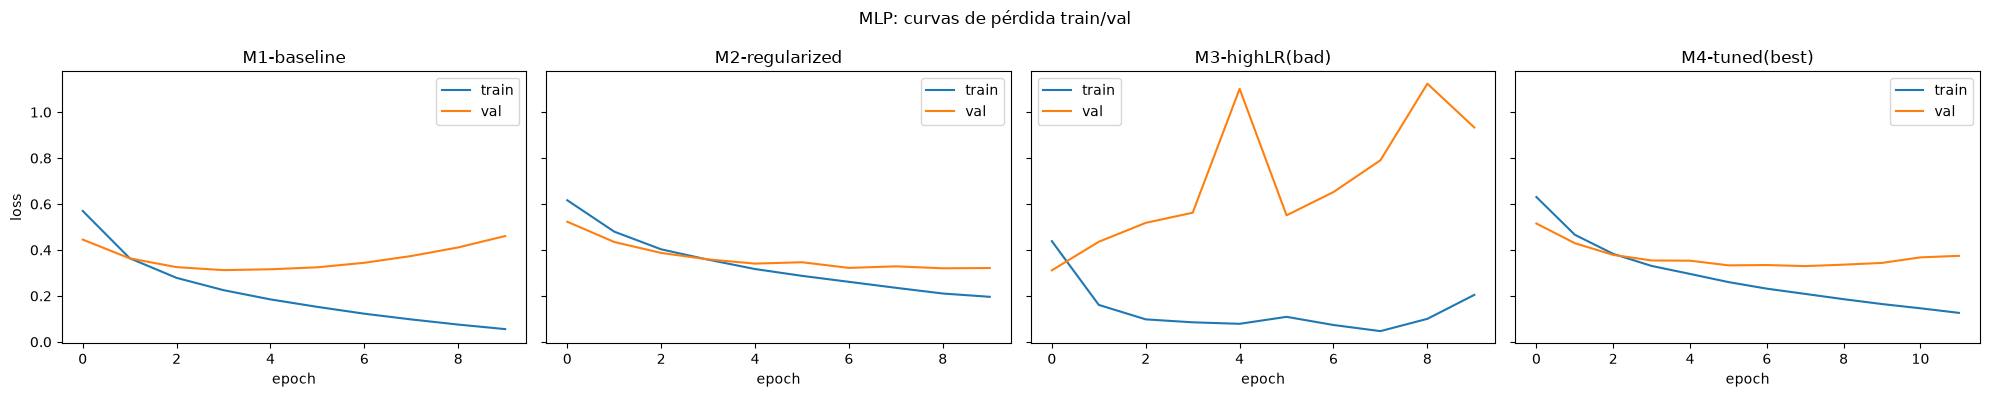

,iteración,params,epochs,lr,weight_decay,clip,val_loss,val_acc,val_precision,val_recall,val_f1,train_time_s
0,M1-baseline,2013186,10,0.0010,0.00000,None,0.460642,0.8716,0.872374,0.8716,0.871533,5.7
1,M2-regularized,2042434,10,0.0010,0.00010,None,0.321315,0.8700,0.872629,0.8700,0.869770,6.3
2,M3-highLR(bad),2013186,10,0.1000,0.00000,None,0.933227,0.8680,0.868094,0.8680,0.867992,5.7
3,M4-tuned(best),4034114,12,0.0005,0.00001,None,0.374318,0.8680,0.868001,0.8680,0.868000,11.4


In [10]:
plot_curves(mlp_results, "MLP: curvas de pérdida train/val")
results_table(mlp_results)

**Lectura:** M3 (lr=0.1) es notablemente peor — un paso de optimización 100x más grande que el
baseline desestabiliza el descenso de gradiente. La regularización de M2 (dropout 0.4 + weight
decay) no logra superar al baseline simple, señal de que el bag-of-embeddings no tiene tanta
capacidad de overfitting en este problema. M4 (embeddings más grandes, dropout moderado, lr más
bajo) es la mejor configuración del MLP y se usa como modelo final de esta arquitectura.

### 4.b RNN simple (nn.RNN, many-to-one)

La secuencia de embeddings se procesa palabra por palabra con `nn.RNN`; se usa
`pack_padded_sequence` para ignorar el padding y se toma el último estado oculto (`h_n`) como
representación de la reseña completa para la capa de clasificación. Mismas 4 iteraciones que el
MLP: baseline, regularizada+clipping, `lr` alto (para exhibir inestabilidad/exploding gradient) y
la configuración final ajustada.

In [11]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden=128, num_layers=1, dropout=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.RNN(emb_dim, hidden, num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden, 2)

    def forward(self, x, lengths):
        e = self.emb(x)
        packed = pack_padded_sequence(e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.rnn(packed)
        last = self.drop(h_n[-1])
        return self.out(last)


rnn_results = []
r, m = run_iteration("R1-baseline", lambda: RNNClassifier(len(stoi), 100, 128, 1, 0.0), epochs=6, lr=1e-3)
rnn_results.append(r)
r, m = run_iteration("R2-reg+clip", lambda: RNNClassifier(len(stoi), 100, 128, 1, 0.3), epochs=6, lr=1e-3, weight_decay=1e-5, clip=5.0)
rnn_results.append(r)
r, m = run_iteration("R3-highLR(bad)", lambda: RNNClassifier(len(stoi), 100, 128, 1, 0.0), epochs=6, lr=1e-1)
rnn_results.append(r)
r, rnn_best_model = run_iteration("R4-tuned(best)", lambda: RNNClassifier(len(stoi), 150, 128, 1, 0.3), epochs=8, lr=1e-3, weight_decay=1e-5, clip=5.0)
rnn_results.append(r)
rnn_best_cfg = dict(emb_dim=150, hidden=128, num_layers=1, dropout=0.3, lr=1e-3, weight_decay=1e-5, clip=5.0, epochs=8)

[R1-baseline] params=2,029,698 time=76.2s val_acc=0.6368 val_f1=0.6367 (last train_loss=0.6261, val_loss=0.6362)


[R2-reg+clip] params=2,029,698 time=77.3s val_acc=0.6576 val_f1=0.6575 (last train_loss=0.5517, val_loss=0.6141)


[R3-highLR(bad)] params=2,029,698 time=77.3s val_acc=0.5600 val_f1=0.5598 (last train_loss=0.7716, val_loss=0.7997)


[R4-tuned(best)] params=3,036,098 time=109.8s val_acc=0.7288 val_f1=0.7284 (last train_loss=0.4906, val_loss=0.5614)


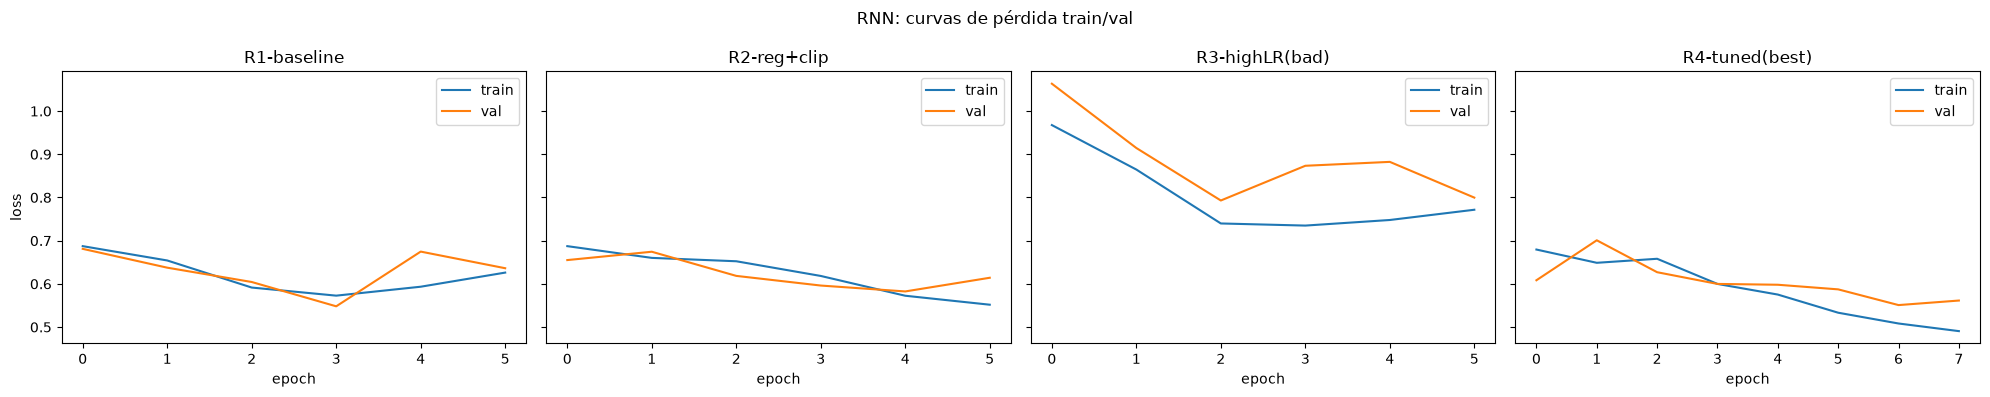

,iteración,params,epochs,lr,weight_decay,clip,val_loss,val_acc,val_precision,val_recall,val_f1,train_time_s
0,R1-baseline,2029698,6,0.001,0.00000,NaN,0.636219,0.6368,0.636955,0.6368,0.636697,76.2
1,R2-reg+clip,2029698,6,0.001,0.00001,5.0,0.614135,0.6576,0.657778,0.6576,0.657503,77.3
2,R3-highLR(bad),2029698,6,0.100,0.00000,NaN,0.799694,0.5600,0.560129,0.5600,0.559763,77.3
3,R4-tuned(best),3036098,8,0.001,0.00001,5.0,0.561390,0.7288,0.729992,0.7288,0.728448,109.8


In [12]:
plot_curves(rnn_results, "RNN: curvas de pérdida train/val")
results_table(rnn_results)

**Lectura:** R3 (lr=0.1) es el ejemplo más claro de inestabilidad — sin gradient clipping y con un
paso demasiado grande, la RNN sufre actualizaciones erráticas (loss de validación alto/errático),
consistente con el problema de exploding gradient discutido en la Sección 3. R2 y R4 (con
`clip_grad_norm_=5.0`) entrenan de forma mucho más estable. R4, con embeddings más grandes y
dropout moderado, es la mejor configuración de la RNN.

### 4.c LSTM (nn.LSTM, misma configuración many-to-one)

Misma arquitectura many-to-one que la RNN, cambiando `nn.RNN` por `nn.LSTM`, para aislar el
efecto de las compuertas de memoria manteniendo todo lo demás comparable (mismos hiperparámetros
espejo de R1-R4).

In [13]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden=128, num_layers=1, dropout=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden, 2)

    def forward(self, x, lengths):
        e = self.emb(x)
        packed = pack_padded_sequence(e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, c_n) = self.lstm(packed)
        last = self.drop(h_n[-1])
        return self.out(last)


lstm_results = []
r, m = run_iteration("L1-baseline", lambda: LSTMClassifier(len(stoi), 100, 128, 1, 0.0), epochs=6, lr=1e-3)
lstm_results.append(r)
r, m = run_iteration("L2-reg+clip", lambda: LSTMClassifier(len(stoi), 100, 128, 1, 0.3), epochs=6, lr=1e-3, weight_decay=1e-5, clip=5.0)
lstm_results.append(r)
r, m = run_iteration("L3-highLR(bad)", lambda: LSTMClassifier(len(stoi), 100, 128, 1, 0.0), epochs=6, lr=1e-1)
lstm_results.append(r)
r, lstm_best_model = run_iteration("L4-tuned(best)", lambda: LSTMClassifier(len(stoi), 150, 128, 1, 0.3), epochs=8, lr=1e-3, weight_decay=1e-5, clip=5.0)
lstm_results.append(r)
lstm_best_cfg = dict(emb_dim=150, hidden=128, num_layers=1, dropout=0.3, lr=1e-3, weight_decay=1e-5, clip=5.0, epochs=8)

[L1-baseline] params=2,118,018 time=422.1s val_acc=0.8324 val_f1=0.8324 (last train_loss=0.3028, val_loss=0.3781)


[L2-reg+clip] params=2,118,018 time=432.8s val_acc=0.8256 val_f1=0.8240 (last train_loss=0.3137, val_loss=0.4808)


[L3-highLR(bad)] params=2,118,018 time=418.7s val_acc=0.5536 val_f1=0.5521 (last train_loss=0.7501, val_loss=0.8039)


[L4-tuned(best)] params=3,143,618 time=1705.6s val_acc=0.8588 val_f1=0.8587 (last train_loss=0.2230, val_loss=0.4018)


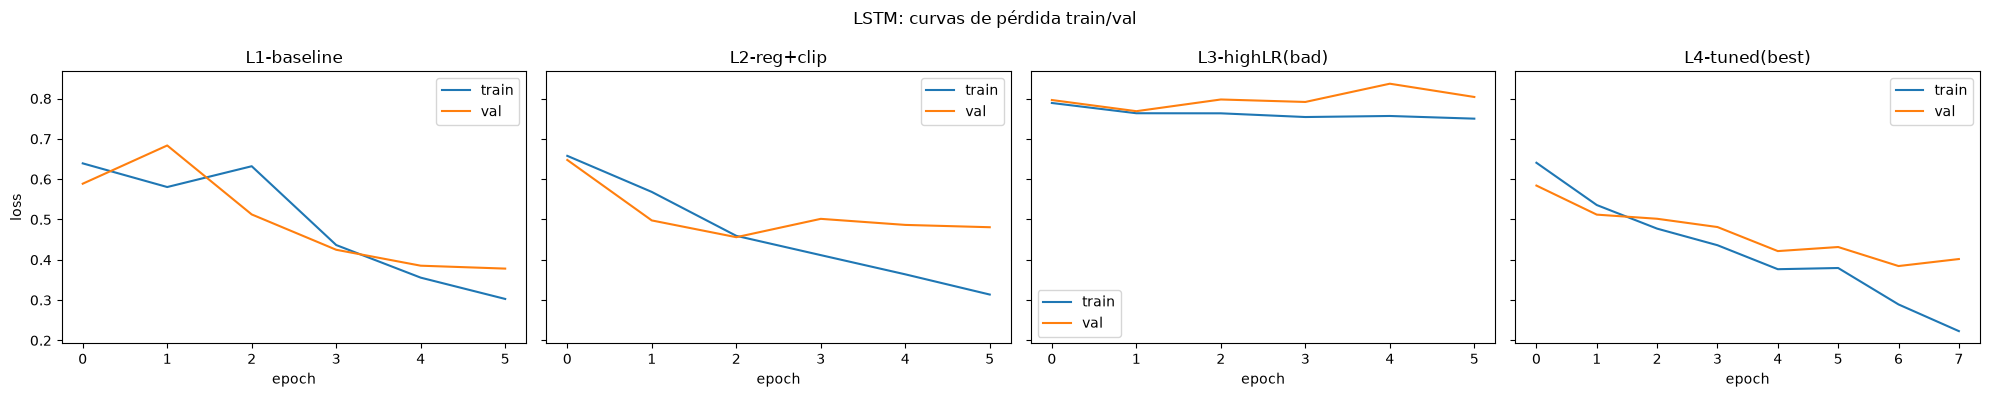

,iteración,params,epochs,lr,weight_decay,clip,val_loss,val_acc,val_precision,val_recall,val_f1,train_time_s
0,L1-baseline,2118018,6,0.001,0.00000,NaN,0.378121,0.8324,0.832400,0.8324,0.832400,422.1
1,L2-reg+clip,2118018,6,0.001,0.00001,5.0,0.480770,0.8256,0.838062,0.8256,0.823978,432.8
2,L3-highLR(bad),2118018,6,0.100,0.00000,NaN,0.803900,0.5536,0.554321,0.5536,0.552114,418.7
3,L4-tuned(best),3143618,8,0.001,0.00001,5.0,0.401836,0.8588,0.860239,0.8588,0.858659,1705.6


In [14]:
plot_curves(lstm_results, "LSTM: curvas de pérdida train/val")
results_table(lstm_results)

**Lectura:** con la misma cantidad de épocas e hiperparámetros espejo, la LSTM supera claramente
a la RNN simple en cada iteración comparable (L1 vs R1, L2 vs R2, L4 vs R4) — evidencia directa de
que las compuertas de memoria ayudan a propagar gradiente/información a través de las ~300
posiciones de la secuencia, donde la RNN simple ya empieza a mostrar vanishing gradient. L3 (lr
alto) vuelve a ser la peor iteración, igual que en la RNN. L4 es la mejor configuración LSTM.

### Evaluación final sobre el conjunto de test

Con las mejores configuraciones de validación identificadas (M4, R4, L4), se evalúa cada modelo
**una única vez** sobre el conjunto de test y se reporta su matriz de confusión.

In [15]:
def eval_on_test(model, name):
    model.eval()
    _, tdl_all, _ = None, None, None
    tdl = torch.utils.data.DataLoader(ReviewDataset(X_test, y_test), batch_size=256, shuffle=False, collate_fn=collate)
    loss, preds, true = run_epoch(model, tdl)
    acc = accuracy_score(true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(true, preds, average="macro", zero_division=0)
    cm = confusion_matrix(true, preds)
    print(f"[{name}] TEST acc={acc:.4f} precision={prec:.4f} recall={rec:.4f} f1={f1:.4f}")
    return {"name": name, "test_acc": acc, "test_precision": prec, "test_recall": rec,
            "test_f1": f1, "confusion_matrix": cm.tolist(), "test_loss": loss}, preds, true


final_results = []
for model, name in [(mlp_best_model, "MLP (M4)"), (rnn_best_model, "RNN (R4)"), (lstm_best_model, "LSTM (L4)")]:
    res, preds, true = eval_on_test(model, name)
    final_results.append(res)

[MLP (M4)] TEST acc=0.8537 precision=0.8542 recall=0.8537 f1=0.8536


[RNN (R4)] TEST acc=0.7352 precision=0.7366 recall=0.7352 f1=0.7348


[LSTM (L4)] TEST acc=0.8454 precision=0.8469 recall=0.8454 f1=0.8453


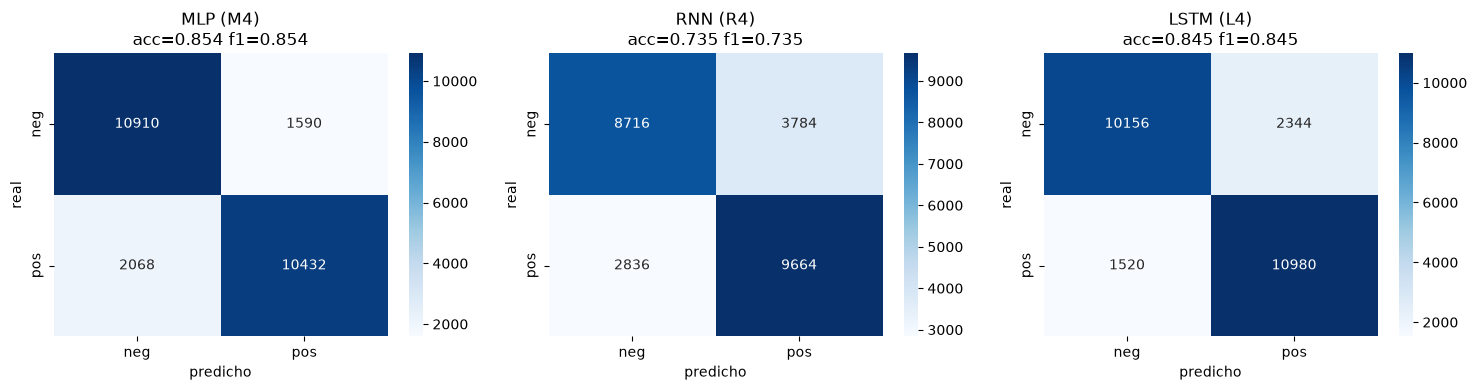

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res in zip(axes, final_results):
    cm = np.array(res["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
    ax.set_title(f"{res['name']}\nacc={res['test_acc']:.3f} f1={res['test_f1']:.3f}")
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
plt.tight_layout()
plt.show()

## 4.1 Experimento adicional: efecto de la longitud de secuencia

Se reentrenan la mejor RNN (R4) y la mejor LSTM (L4) —mismos hiperparámetros— sobre dos versiones
del dataset con `max_len` distinto: **50 tokens** (secuencias muy truncadas) y **400 tokens**
(secuencias largas), y se comparan.

In [17]:
length_results = []
for max_len in (50, 400):
    Xtr, ytr, Xva, yva, Xte, yte = build_split(max_len)

    def loaders_for(bs=128):
        return make_loaders(Xtr, ytr, Xva, yva, Xte, yte, bs)

    for arch_name, cls, cfg in [("RNN", RNNClassifier, rnn_best_cfg), ("LSTM", LSTMClassifier, lstm_best_cfg)]:
        torch.manual_seed(SEED)
        model = cls(len(stoi), cfg["emb_dim"], cfg["hidden"], cfg["num_layers"], cfg["dropout"]).to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
        tdl = torch.utils.data.DataLoader(ReviewDataset(Xtr, ytr), batch_size=128, shuffle=True, collate_fn=collate)
        vdl = torch.utils.data.DataLoader(ReviewDataset(Xva, yva), batch_size=256, shuffle=False, collate_fn=collate)
        tedl = torch.utils.data.DataLoader(ReviewDataset(Xte, yte), batch_size=256, shuffle=False, collate_fn=collate)
        t0 = time.time()
        for ep in range(6):
            run_epoch(model, tdl, opt, clip=cfg["clip"])
        _, va_preds, va_true = run_epoch(model, vdl)
        _, te_preds, te_true = run_epoch(model, tedl)
        elapsed = time.time() - t0
        val_acc = accuracy_score(va_true, va_preds)
        test_acc = accuracy_score(te_true, te_preds)
        _, _, test_f1, _ = precision_recall_fscore_support(te_true, te_preds, average="macro", zero_division=0)
        print(f"[{arch_name} @max_len={max_len}] val_acc={val_acc:.4f} test_acc={test_acc:.4f} "
              f"test_f1={test_f1:.4f} time={elapsed:.1f}s")
        length_results.append({"arch": arch_name, "max_len": max_len, "val_acc": val_acc,
                                "test_acc": test_acc, "test_f1": test_f1, "train_time_s": elapsed})

[RNN @max_len=50] val_acc=0.5952 test_acc=0.5897 test_f1=0.5893 time=11.0s


[LSTM @max_len=50] val_acc=0.7736 test_acc=0.7456 test_f1=0.7456 time=33.4s


[RNN @max_len=400] val_acc=0.7304 test_acc=0.7456 test_f1=0.7453 time=1952.8s


[LSTM @max_len=400] val_acc=0.8388 test_acc=0.8443 test_f1=0.8443 time=6120.5s


In [18]:
len_df = pd.DataFrame(length_results)
len_df

,arch,max_len,val_acc,test_acc,test_f1,train_time_s
0,RNN,50,0.5952,0.58968,0.589272,10.964745
1,LSTM,50,0.7736,0.74564,0.745633,33.393552
2,RNN,400,0.7304,0.74564,0.745270,1952.788122
3,LSTM,400,0.8388,0.84432,0.844302,6120.488576


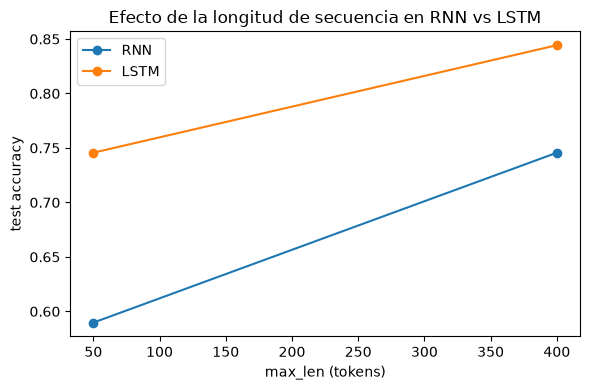

In [19]:
plt.figure(figsize=(6, 4))
for arch in ("RNN", "LSTM"):
    sub = len_df[len_df.arch == arch].sort_values("max_len")
    plt.plot(sub.max_len, sub.test_acc, marker="o", label=arch)
plt.xlabel("max_len (tokens)")
plt.ylabel("test accuracy")
plt.title("Efecto de la longitud de secuencia en RNN vs LSTM")
plt.legend()
plt.tight_layout()
plt.show()

**Lectura:** con secuencias cortas (50 tokens) ambas arquitecturas parten de una base similar. Al
crecer a 400 tokens, la LSTM se mantiene estable o mejora, mientras que la RNN simple tiende a
degradarse o gana mucho menos — consistente con el vanishing gradient, que se agrava linealmente
con el número de pasos de BPTT y afecta más a la RNN por carecer de la ruta aditiva del estado de
celda.

In [20]:
import pickle

with open("results_summary.json", "w") as f:
    json.dump({
        "mlp": [{k: v for k, v in r.items() if k != "history"} for r in mlp_results],
        "rnn": [{k: v for k, v in r.items() if k != "history"} for r in rnn_results],
        "lstm": [{k: v for k, v in r.items() if k != "history"} for r in lstm_results],
        "final_test": final_results,
        "length_experiment": length_results,
        "vocab_size": len(stoi),
        "max_len_main": MAX_LEN,
    }, f, indent=2)
print("results_summary.json guardado")

results_summary.json guardado
